# Credit Card Fraud detection

Kaggle dataset available [here.](https://www.kaggle.com/datasets/kartik2112/fraud-detection)

### Project overview
This notebook explores a dataset of banking transactions between customers and merchants with the objective of detecting fraudulent activity. The goal is to build a classification model that can identify fraudulent transactions as accurately as possible.

Each transaction includes information such as timestamp, transaction amount, customer and merchant identifiers, category, geographic location, and a label indicating whether the transaction is fraudulent or legitimate. The target variable, *is_fraud*, represents whether a transaction is fraudulent (1) or legitimate (0).

### Fraud Detection Approach

The model outputs a probability of fraud for each transaction rather than a simple binary prediction. To translate this probability into an actionable decision (fraud / non-fraud), a decision threshold is applied: transactions with an estimated probability above the threshold are classified as fraudulent.

### Evaluation Focus

Special attention is given to false positives and false negatives:

- False positives: legitimate transactions incorrectly flagged as fraudulent

- False negatives: fraudulent transactions that are not detected

Both error types have important economic and operational implications, though their costs differ.

### Threshold Optimization

A key challenge of the problem is selecting an appropriate decision threshold. This choice determines the trade-off between:

- High recall, capturing as many fraudulent transactions as possible

- High precision, minimizing unnecessary fraud alerts

The analysis therefore focuses on identifying an optimal threshold that maximizes the overall effectiveness of the fraud detection system.

In [37]:
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingClassifier
from scipy.stats import ks_2samp
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, average_precision_score, classification_report
import shap
import joblib

In [38]:
# Load test and train df

data_folder = "data"
dataTest  = pd.read_csv(os.path.join(data_folder,'fraudTest.csv'))
dataTrain = pd.read_csv(os.path.join(data_folder,'fraudTrain.csv'))

### Exploratory analysis

The training dataset has 1296675 entries and no null values.

In [39]:
dataTrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

The test dataset has 555719 entries and no null values.

In [40]:
dataTest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

Setting the date column as index column for both datasets.

In [41]:
def set_index_time(df):
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df.set_index('trans_date_trans_time', inplace=True)

    return df

dataTest=set_index_time(dataTest)
dataTrain= set_index_time(dataTrain)


Since the cost of a false negative (undetected fraud) is typically much higher than that of a false positive (legitimate trnasactions labeled as fraudolent), decision thresholds and evaluation metrics (e.g. Precision–Recall curves) are chosen to prioritize fraud detection while limiting false alerts.

### Feature analysis
Let's analyze the distributions of amount per transaction (*amt*) in the case of legitimate and in the case of fraudolent transactions.

A clear difference is noticable between the two cases. The column *amt* can be exploited to build a feature to help improving the performance of the detection model.

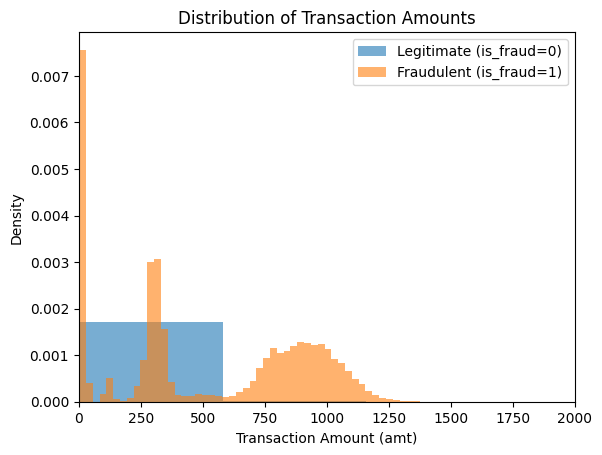

In [42]:
import matplotlib.pyplot as plt

# Split the data
amt_legit = dataTrain.loc[dataTrain["is_fraud"] == 0, "amt"]
amt_fraud = dataTrain.loc[dataTrain["is_fraud"] == 1, "amt"]

# Plot distributions
plt.figure()
plt.hist(amt_legit, bins=50, alpha=0.6, label="Legitimate (is_fraud=0)", density=True)
plt.hist(amt_fraud, bins=50, alpha=0.6, label="Fraudulent (is_fraud=1)", density=True)

plt.xlabel("Transaction Amount (amt)")
plt.ylabel("Density")
plt.legend()
plt.title("Distribution of Transaction Amounts")
plt.xlim([0,2000]) # zoom in the range (0,2000) to better appreciate the distributions

plt.show()


In [43]:
# Dataframe of only fraudolent transaction entries
fraud_df = dataTrain[dataTrain['is_fraud'] == 1]

Let's analyze the distribution of the feature *category*.

The two distributions appear quite different, hence *category* can be used to enhance the model performance. 

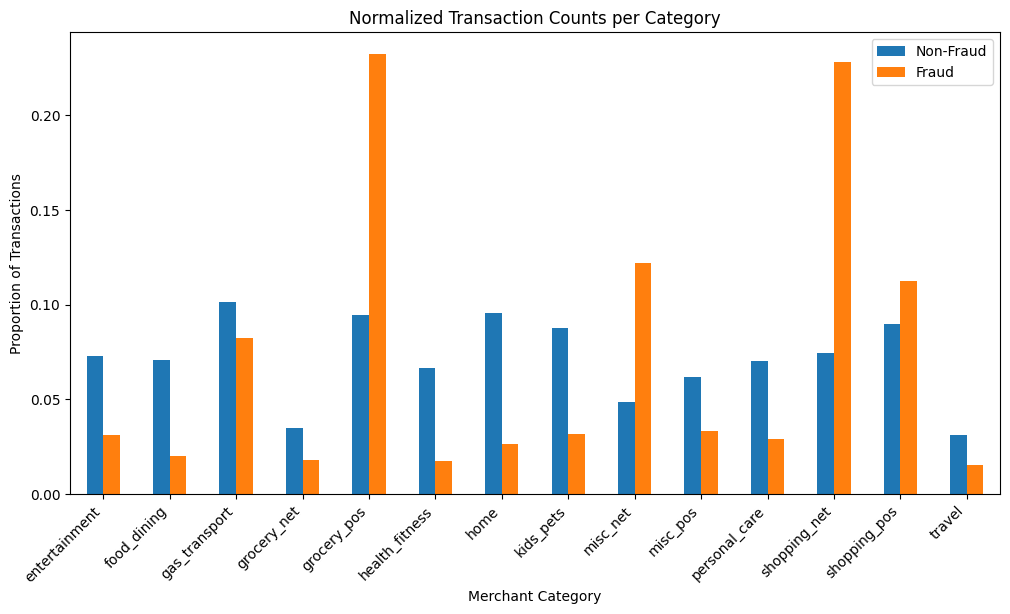

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# Count transactions per category for each class
category_count_non_fraud = dataTrain[dataTrain['is_fraud'] == 0].groupby('category')['amt'].count()
category_count_fraud = dataTrain[dataTrain['is_fraud'] == 1].groupby('category')['amt'].count()

# Normalize each by the total count of that class
category_count_non_fraud_norm = category_count_non_fraud / category_count_non_fraud.sum()
category_count_fraud_norm = category_count_fraud / category_count_fraud.sum()

# Combine into a single DataFrame for side-by-side plotting
category_counts_norm = pd.DataFrame({
    'Non-Fraud': category_count_non_fraud_norm,
    'Fraud': category_count_fraud_norm
}).fillna(0)  # in case some categories have 0 fraud

# Plot side-by-side bars (staggered)
category_counts_norm.plot(kind='bar', figsize=(12,6))
plt.xlabel('Merchant Category')
plt.ylabel('Proportion of Transactions')
plt.title('Normalized Transaction Counts per Category')
plt.xticks(rotation=45, ha='right')
plt.show()


Now let's study the distance between merchant and customer.

To do so, let's build a distance feature based on the latitude and longitude information available both for the merchant and the customer based on the Haversine distance.

As it is clear from the plot, the two distridutions are almost perfectly overlapped, meaning there is no major difference between the merchant-customer distance for fraudolent and non-fraudolent transactions.

In [45]:
def haversine_distance(lat1, lon1, lat2, lon2):

    R= 6371  # Mean earth radius in km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat= lat2 - lat1
    dlon= lon2 - lon1

    a= (np.sin(dlat / 2)**2 +np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2)
    c= 2 * np.arcsin(np.sqrt(a))

    return R * c

def calc_distance(df):
    df['distance_km'] = haversine_distance(df['lat'], df['long'], df['merch_lat'],  df['merch_long'])
    return df


/tmp/ipykernel_1267/2165786324.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['distance_km'] = haversine_distance(df['lat'], df['long'], df['merch_lat'],  df['merch_long'])
/tmp/ipykernel_1267/2165786324.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['distance_km'] = haversine_distance(df['lat'], df['long'], df['merch_lat'],  df['merch_long'])


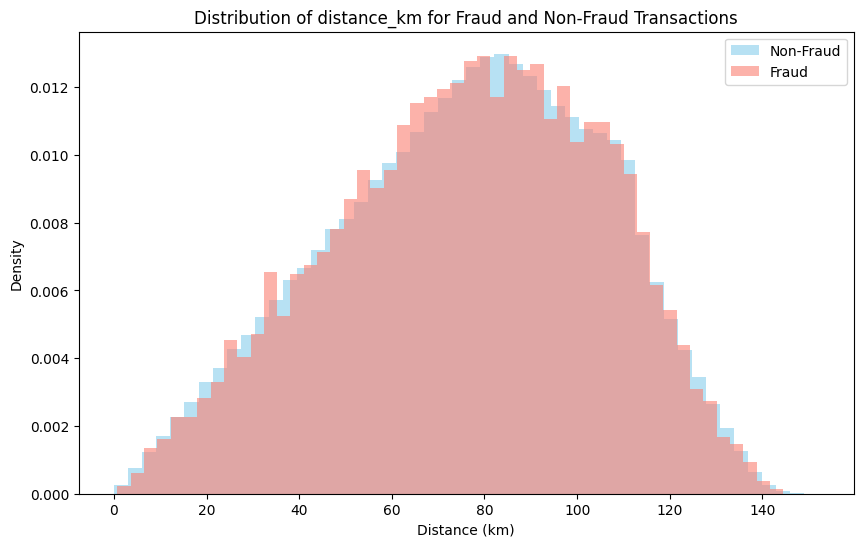

In [46]:
non_fraud_df = calc_distance(dataTrain[dataTrain['is_fraud'] == 0])
fraud_df = calc_distance(dataTrain[dataTrain['is_fraud'] == 1])

# Plot histograms
plt.figure(figsize=(10,6))
plt.hist(non_fraud_df['distance_km'], bins=50, alpha=0.6, label='Non-Fraud', color='skyblue', density=True)
plt.hist(fraud_df['distance_km'], bins=50, alpha=0.6, label='Fraud', color='salmon', density=True)

plt.xlabel('Distance (km)')
plt.ylabel('Density')
plt.title('Distribution of distance_km for Fraud and Non-Fraud Transactions')
plt.legend()
plt.show()


### Feature Engineering

Customer-level information is derived from the transaction identifier (*cc_num*). Starting from this variable, we can compute aggregated features such as the customer’s total, average, and maximum spending, as well as the total number of transactions.

In addition, we can analyze the average time between transactions for each customer.

Among the most informative factors for detecting payment fraud are the customer–merchant distance and transaction amounts that deviate from a customer’s typical spending behavior.

From both the training and test datasets, we remove some variables that are not meaningful for the analysis.

In [47]:
def feature_eng(df):
    # Number of transactions, total amount and mean amount spent per client
    df['tot_transaction']    = df.groupby('cc_num')['amt'].transform('count')
    df['client_total_spent'] = df.groupby('cc_num')['amt'].transform('sum')
    df['client_avg_amt']     = df.groupby('cc_num')['amt'].transform('mean')

    # Hour, day and month of the transaction
    df['hour']  = df.index.hour
    df['day']   = df.index.day
    df['month'] = df.index.month

    # Mean time transactions
    df['transaction_rate_hourly'] = df.groupby('cc_num')['hour'].transform('mean')

    df = df.drop(columns=['Unnamed: 0', 'first', 'last', 'street', 'dob'])

    return df

dataTrain = feature_eng(dataTrain)
dataTest  = feature_eng(dataTest)

### Preprocessing

Using OrdinalEncoder to transform categorical columns into a numeric range and applying standardization to the numeric columns.

In [48]:
def preprocessing_train(dataTrain, dataTest):

    dataTrain_p = dataTrain.copy()
    dataTest_p  = dataTest.copy()

    num_cols = dataTrain_p.select_dtypes(include=['int64', 'float64']).columns.drop('is_fraud')
    cat_cols = dataTrain_p.select_dtypes(include='object').columns

    scaler = StandardScaler()
    oe     = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

    dataTrain_p[num_cols] = scaler.fit_transform(dataTrain_p[num_cols])
    dataTrain_p[cat_cols] = oe.fit_transform(dataTrain_p[cat_cols])

    dataTest_p[num_cols] = scaler.transform(dataTest_p[num_cols])
    dataTest_p[cat_cols] = oe.transform(dataTest_p[cat_cols])

    dfTrain = dataTest_p
    dfTest= dataTrain_p

    return dfTrain, dfTest

dfTrain, dfTest = preprocessing_train(dataTrain, dataTest)

We now analyze how each customer’s purchasing behavior evolves over time using the unix_time variable.

To do this, we apply a moving average, computed over the five preceding transactions, in order to capture short-term changes in transaction timing and spending patterns.

In [49]:
def feature_eng_adv(df):
    df['time_since_last_tx'] = df.groupby('cc_num')['unix_time'].diff() # Seconds from last transaction
    df['mavg_last_five_tx'] = df.groupby('cc_num')['time_since_last_tx'].transform(lambda x: x.shift().rolling(5).mean()) # Moving average
    df['mstd_dev_last_five_tx'] = df.groupby('cc_num')['time_since_last_tx'].transform(lambda x: x.shift().rolling(5).std()) # Moving average deviation
    df['z_score_tx'] = (df['time_since_last_tx']-df['mavg_last_five_tx'])/df['mstd_dev_last_five_tx']
    df['outlier_tx'] = df['z_score_tx'].abs() > 2 # Considering a 95% confidence interval, the absolute value of the z-score must be below 2 for a data point not to be considered an outlier of the distribution.

    df['new_purchase'] = df.groupby('cc_num')['merchant'].transform(lambda x: ~x.shift().isin(x.shift())).fillna(True)
    df['new_category'] = df.groupby('merchant')['category'].transform(lambda x: ~x.shift().isin(x.shift())).fillna(True)

    return df

dfTrain = feature_eng_adv(dfTrain)
dfTest = feature_eng_adv(dfTest)

Finally, we adopt a simplified HMM-based analysis applied to two sequences: customer–amount and customer–time between transactions.

Instead of performing a full Hidden Markov Model analysis, we rely on a likelihood proxy, which does not explicitly model latent states but still measures the deviation between the expected value of a variable given the sequence and its observed value.

In [50]:
def simpler_hmm(df):
    df['ma_amt_5'] = df.groupby('cc_num')['amt'].transform(lambda x: x.shift().rolling(5).mean())
    df['mstd_amt_5'] = df.groupby('cc_num')['amt'].transform(lambda x: x.shift().rolling(5).std())
    df['z_score_amt'] = (df['amt']-df['ma_amt_5'])/df['mstd_amt_5']
    df['amt_likelihood'] =  np.abs(df['amt'] - df['ma_amt_5']) / (df['mstd_amt_5'] + 1e-6)

    
    # Customer likelihood and time between transactions
    df['tx_likelihood'] =  np.abs(df['time_since_last_tx'] - df['mavg_last_five_tx']) / (df['mstd_dev_last_five_tx'] + 1e-6)

    return df


dfTrain = simpler_hmm(dfTrain)
dfTest = simpler_hmm(dfTest)

### Null values handling

Some of the features computed during preprocessing contain NaN values. Since the dataset represents a time series of transactions, these NaNs do not arise from missing data, but rather from the lack of sufficient historical information for certain observations (for example, the first transactions of a customer or rolling windows that are not yet fully populated).

For this reason, it is neither appropriate to compute a global mean nor to drop rows containing NaN values, as doing so would result in information loss and would distort the temporal structure of the dataset.

A dedicated function is therefore implemented to handle NaN values in a feature-specific manner.

In particular, for the feature representing the time elapsed between consecutive transactions, NaN values are replaced with the median of the column.

Rolling features are handled differently:

- for rolling means, NaN values are replaced with coherent reference values, such as the customer’s average spending or average traveled distance;

- for rolling standard deviations, NaN values are replaced with 0, since a zero standard deviation indicates no deviation from the expected value.

The same strategy is applied to z-scores, likelihood proxies, and transaction rates, for which a value of 0 represents a neutral condition.

In [51]:
def nan_values(df):
    df = df.copy()

    if 'time_since_last_tx' in df.columns:
        df['is_first_tx'] = df['time_since_last_tx'].isna().astype(int)
        df['time_since_last_tx'] = df['time_since_last_tx'].fillna(df['time_since_last_tx'].median())

    rolling_mean_fallback = {'mavg_last_five_tx': 'amt','ma_amt_5': 'amt','mavg_last_five_dist': 'distance_km'}

    for col, fallback in rolling_mean_fallback.items():
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isna().astype(int)
            df[col] = df[col].fillna(df[fallback])

    rolling_std_cols = ['mstd_dev_last_five_tx','mstd_dev_last_five_dist','mstd_amt_5']

    for col in rolling_std_cols:
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isna().astype(int)
            df[col] = df[col].fillna(0)

    zscore_cols = ['z_score_tx','z_score_dist','z_score_amt']

    for col in zscore_cols:
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isna().astype(int)
            df[col] = df[col].fillna(0)

    likelihood_cols = ['amt_likelihood','tx_likelihood']

    for col in likelihood_cols:
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isna().astype(int)
            df[col] = df[col].fillna(0)


    if 'tx_qnt' in df.columns:
        df['tx_qnt_missing'] = df['tx_qnt'].isna().astype(int)
        df['tx_qnt'] = df['tx_qnt'].fillna(0)

    return df


dfTrain = nan_values(dfTrain)
dfTest  = nan_values(dfTest)

### Modeling

As shown in the plot below, the dataset is highly imbalanced, with only about 0.58% of the observations belonging to class 1 (fraudulent transactions).

In the presence of such a strong class imbalance, it is necessary to adopt a rebalancing strategy. Using the raw data directly would lead the model to favor the majority class, resulting in seemingly high performance metrics that are of limited operational value.

In this case, since the data represent a time series of transactions, the most appropriate strategy is the use of class weights. Unlike sampling techniques, this approach neither generates synthetic observations nor removes instances from the majority class, but instead directly modifies the model’s loss function.

Specifically, observations belonging to the minority class are assigned a higher weight during training, increasing the penalty for misclassifying fraudulent transactions. This encourages the model to focus more on fraud detection while preserving the original temporal structure of the dataset.

In [52]:
counts_train = dfTrain['is_fraud'].value_counts()
counts_test = dfTest['is_fraud'].value_counts() 
print('Train set:\n', counts_train,'\n')
print('Test set:\n',counts_test)

Train set:
 0    553574
1      2145
Name: is_fraud, dtype: int64 

Test set:
 0    1289169
1       7506
Name: is_fraud, dtype: int64


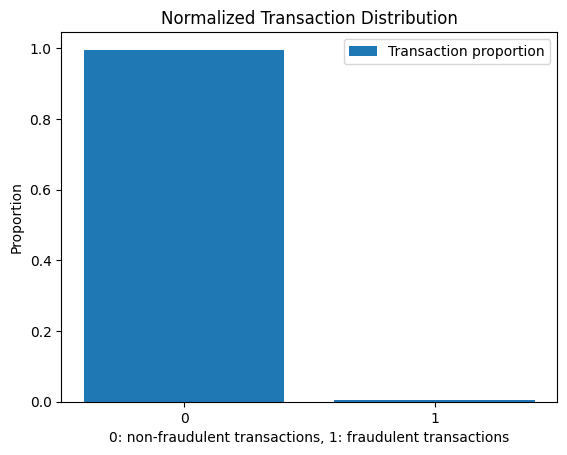

In [53]:
# Normalize counts
counts_train_norm = counts_train / counts_train.sum()

plt.bar(counts_train_norm.index.astype(str), counts_train_norm.values, label='Transaction proportion')

plt.xlabel('0: non-fraudulent transactions, 1: fraudulent transactions')
plt.ylabel('Proportion')
plt.title('Normalized Transaction Distribution')
plt.legend()
plt.show()

Let's define some useful functions for modeling

In [54]:
def get_X_y(dfTrain, dfTest):  
    X_train = dfTrain.drop('is_fraud', axis=1)
    X_test = dfTest.drop('is_fraud', axis=1)
    y_train = dfTrain['is_fraud']
    y_test = dfTest['is_fraud']

    return X_test, X_train, y_test, y_train

X_test, X_train, y_test, y_train = get_X_y(dfTrain, dfTest)

In [55]:
def train_logistic_regression(X_train, y_train):
    model = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)
    return model


def predict_proba_logistic(model, X_test):
    return model.predict_proba(X_test)[:, 1]

Implemento ora l'algoritmo di XGBoosting 

In [56]:
def train_xgb_classifier(X_train, y_train):
    scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
    model = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train, y_train)
    return model


def predict_proba_xgb(model, X_test):
    return model.predict_proba(X_test)[:, 1]

Computing the class probability estimates produced by the model for each observation in the test dataset.
Focusing on the probability associated with class 1 (fraud), I extract the information needed to compute evaluation metrics such as PR-AUC, precision, recall, and F1-score.

The model’s estimated probability is converted into a binary prediction by applying a decision threshold: if the probability that a transaction belongs to class 1 exceeds this threshold, the transaction is classified as fraudulent.

The threshold value is selected based on the trade-off between false positives and false negatives. Increasing the threshold reduces the number of false positives but increases the risk of missing real frauds, while lowering the threshold allows more frauds to be detected at the cost of a higher number of legitimate transactions being incorrectly flagged.

Let's then compute the following evaluation metrics:

Precision: the proportion of true frauds among all transactions flagged as fraudulent;

Recall: the proportion of actual frauds that are correctly detected;

F1-score: the harmonic mean of precision and recall, summarizing the balance between the two metrics.

In [33]:
threshold = [0.1, 0.2, 0.3, 0.4, 0.5]

def evaluate_thresholds(y_true, y_proba, thresholds, model_name="Model"):
    for t in thresholds:
        y_pred = (y_proba > t).astype(int)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        print(f"{model_name} | Soglia: {t:.2f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-score:  {f1:.4f}\n")

In [58]:
lr_model = train_logistic_regression(X_train, y_train)
y_proba_lr = predict_proba_logistic(lr_model, X_test)

/home/devcontainers/sure_venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [59]:
xgb_model = train_xgb_classifier(X_train, y_train)
y_proba_xgb = predict_proba_xgb(xgb_model, X_test)

In [60]:
# Saving xgoboost model
joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']

In [61]:
evaluate_thresholds(y_test, y_proba_lr, threshold, "Logistic")
evaluate_thresholds(y_test, y_proba_xgb, threshold, "XGBoost")

Logistic | Soglia: 0.10
Precision: 0.0058
Recall:    1.0000
F1-score:  0.0115

Logistic | Soglia: 0.20
Precision: 0.0058
Recall:    1.0000
F1-score:  0.0115

Logistic | Soglia: 0.30
Precision: 0.0058
Recall:    1.0000
F1-score:  0.0115

Logistic | Soglia: 0.40
Precision: 0.0058
Recall:    1.0000
F1-score:  0.0115

Logistic | Soglia: 0.50
Precision: 0.0058
Recall:    1.0000
F1-score:  0.0115

XGBoost | Soglia: 0.10
Precision: 0.6948
Recall:    0.9134
F1-score:  0.7892

XGBoost | Soglia: 0.20
Precision: 0.7975
Recall:    0.8814
F1-score:  0.8374

XGBoost | Soglia: 0.30
Precision: 0.8500
Recall:    0.8552
F1-score:  0.8526

XGBoost | Soglia: 0.40
Precision: 0.8832
Recall:    0.8331
F1-score:  0.8574

XGBoost | Soglia: 0.50
Precision: 0.9086
Recall:    0.8091
F1-score:  0.8560



As can be observed from the outputs, the precision and recall values achieved by the Logistic Regression model are less satisfactory than those obtained with the XGBoost (XGB) algorithm. This is primarily because logistic regression is a linear model, which struggles to capture complex and non-linear relationships between the explanatory variables and the probability of fraud.

In contrast, XGBoost benefits from its boosting mechanism, which progressively focuses on the most difficult-to-classify observations. This allows the model to improve performance especially on rare classes, leading to higher recall in fraud detection.

From the analysis of metrics obtained by varying the decision threshold, it is clear that the choice of threshold has a significant impact on model performance, particularly for the minority class (fraud).

With a low threshold (0.10), the model detects nearly all fraudulent transactions, as reflected by a recall close to 1. However, this high recall comes at the cost of low precision, indicating a large number of false positives. In this scenario, the model is very sensitive but not very selective.

As the decision threshold is gradually increased, precision for class 1 improves significantly, accompanied by a slight reduction in recall. This behavior aligns with the typical precision–recall trade-off: the model becomes more conservative, flagging fewer transactions as fraudulent, but doing so more reliably.

For thresholds between 0.30 and 0.40, a good balance is achieved between the two metrics, with a notable increase in the F1-score for the fraudulent class. This indicates an effective compromise between fraud detection and minimizing false positives.

At a threshold of 0.50, the model becomes even more selective: precision continues to increase, while recall decreases only slightly. This scenario is preferable in contexts where the cost of false positives is high and it is important to limit the number of transactions flagged as suspicious.

##### Computing the best threshold
Determining the decision threshold that yields the maximum F1-score for the XGBoost model, as this metric represents the optimal balance between precision and recall.

In [62]:
def find_best_f1_threshold(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1)
    return thresholds[best_idx], f1[best_idx]

best_t, best_f1 = find_best_f1_threshold(y_test, y_proba_xgb)
print(f"Best threshold (F1): {best_t:.3f} | F1: {best_f1:.4f}")


Best threshold (F1): 0.467 | F1: 0.8583


For a final comparison between the XGBoost and Logistic Regression models, the Precision–Recall Area Under the Curve (PR-AUC) is also computed. \
The results confirm the observations from previous analyses.

From the Precision–Recall curves, it is evident that XGBoost outperforms Logistic Regression across the entire range of recall, consistently maintaining higher precision values.
In contrast, Logistic Regression demonstrates limited ability to separate fraudulent transactions, with precision dropping sharply even at low recall levels.

In [63]:
def compute_pr_auc(y_true, y_proba):
    return average_precision_score(y_true, y_proba)

print("LR PR-AUC:", compute_pr_auc(y_test, y_proba_lr))
print("XGB PR-AUC:", compute_pr_auc(y_test, y_proba_xgb))

LR PR-AUC: 0.0057890133688726
XGB PR-AUC: 0.9189271085965517


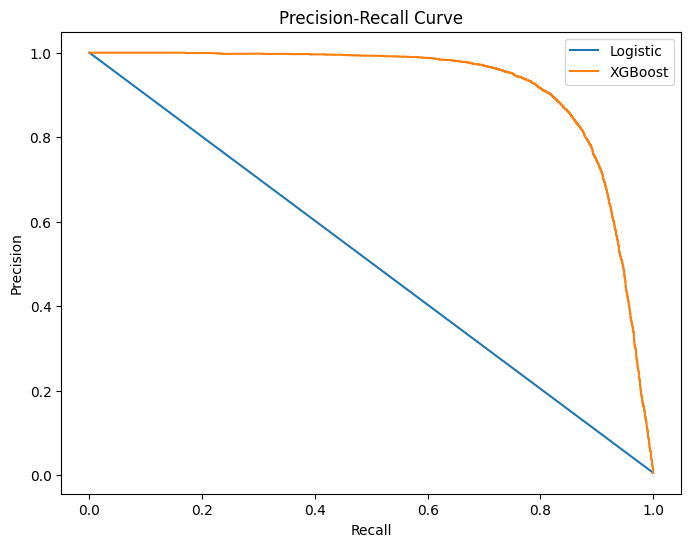

In [64]:
def plot_pr_curves(y_true, proba_dict):
    plt.figure(figsize=(8, 6))

    for name, y_proba in proba_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        plt.plot(recall, precision, label=name)

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()


plot_pr_curves(y_test,{"Logistic": y_proba_lr,"XGBoost": y_proba_xgb})

### Models interpretability

Model interpretability was approached on multiple levels: by analyzing the coefficients of the Logistic Regression, examining feature importance in the XGBoost model, and using SHAP to provide detailed explanations of predictions at both the global and local level.

We begin by examining the coefficients of the Logistic Regression model, which allow us to identify the features with the greatest linear impact on the probability of fraud.

In [65]:
def coeff_regr(model, X_train):
    coef_df = pd.DataFrame({'feature': X_train.columns,'coefficient': model.coef_[0]})

    # Taking the absolute values of the coefficients and reordering in ascending order
    coef_df['abs_coef'] = coef_df['coefficient'].abs()
    coef_df = coef_df.sort_values('abs_coef', ascending=False)

    return coef_df

In [66]:
# Let's now consider the first 10 coefficients, The ones that most influence the analysis
coef_df = coeff_regr(lr_model, X_train)
coef_df.head(10)

,feature,coefficient,abs_coef
30,ma_amt_5,2.020403,2.020403
3,amt,1.088627,1.088627
17,client_total_spent,-0.873689,0.873689
13,unix_time,-0.768733,0.768733
4,gender,-0.575414,0.575414
12,trans_num,0.467797,0.467797
18,client_avg_amt,0.433051,0.433051
19,hour,-0.279598,0.279598
16,tot_transaction,-0.197627,0.197627
33,amt_likelihood,0.184629,0.184629


By analyzing the feature importance of the XGBoost model, we can identify which features the model relies on most.
Using the gain method, we can measure how much each feature contributes to improving the model’s decisions.

As observed, the Gradient Boosting–based model primarily leverages temporal and behavioral features.

In [67]:
def feat_importance(model):
    importance = model.get_booster().get_score(importance_type='gain')

    imp_df = pd.DataFrame(importance.items(), columns=['feature', 'importance']).sort_values('importance', ascending=False)
    print(imp_df)
    return imp_df, importance

importance, imp_df = feat_importance(xgb_model)

                      feature    importance
26                   ma_amt_5  15786.060547
3                         amt   6199.007812
27                 mstd_amt_5   3674.535400
18                       hour   1836.739136
2                    category   1137.326538
17             client_avg_amt   1088.411377
28                z_score_amt    940.820374
29             amt_likelihood    631.065430
7                         zip    570.496521
24      mstd_dev_last_five_tx    490.055359
22         time_since_last_tx    414.274902
31                is_first_tx    384.350525
12                  unix_time    364.483765
16         client_total_spent    361.026520
23          mavg_last_five_tx    355.047089
4                      gender    352.874176
10                   city_pop    333.337982
30              tx_likelihood    323.770935
5                        city    244.531601
21    transaction_rate_hourly    212.390335
6                       state    190.038055
11                        job   

Finally, we perform a SHAP analysis, which provides a deeper understanding of the model’s behavior and the factors driving individual predictions.

In the SHAP plot, features are ordered by their importance in shaping the model’s output. The baseline prediction corresponds to the dataset’s average risk, which in our case is approximately 0.58%, the mean probability of fraud.

For each transaction, the model’s final predicted probability is obtained by adding this baseline value to the contributions of each feature, represented by their SHAP values.

Points to the right of the horizontal axis indicate features that increase the predicted probability of fraud, while points to the left indicate features that decrease it. The color of the points reflects the feature value: red for high values and blue for low values.

SHAP analysis thus allows us to identify which factors led the model to consider a transaction more or less risky, providing both a global explanation of the model’s behavior and a local explanation for individual predictions.

In [187]:
def shap_expl(model, X_test):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    return explainer, shap_values

explainer, shap_values= shap_expl(xgb_model, X_test)

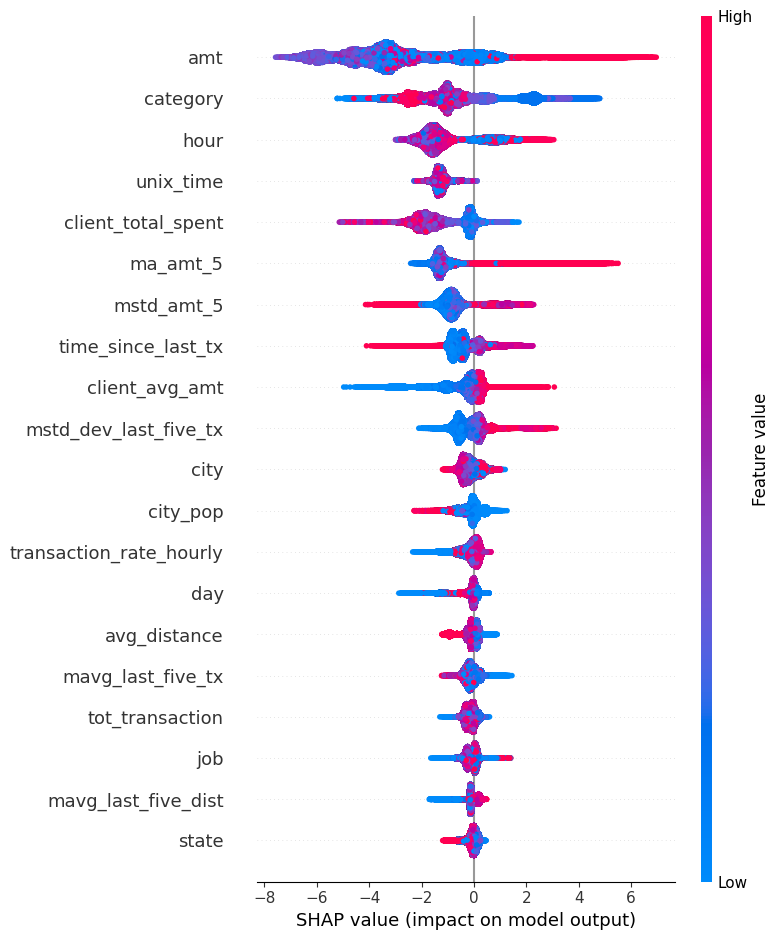

In [188]:
def shap_plot(shap_values, X_test):
    shap.summary_plot(shap_values, X_test)

shap_plot(shap_values, X_test)

The SHAP plot clearly highlights several key features driving the model’s decisions. First, the transaction amount (amt) is a highly influential factor. Higher amounts tend to push the prediction toward the fraudulent class, while lower amounts reduce the estimated risk, confirming the importance of spending-related information in detecting anomalous transactions.

In addition, temporal features, particularly hour and time_since_last_tx, also have a significant impact. Transactions occurring at unusual hours or at anomalous intervals compared to a customer’s transaction history increase the predicted fraud risk, emphasizing the role of temporal patterns in the model.

### Pipeline prototyping

Design and implementation of classes with associated methods, enabling greater modularity and code reuse.

In [ ]:
class Fraud_detector():
    def __init__(self):
        pass
    
    @staticmethod
    def haversine_distance(lat1, lon1, lat2, lon2):
        R = 6371
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat / 2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon / 2)**2
        c = 2 * np.arcsin(np.sqrt(a))
        return R * c
    
    def calc_distance(self, df):
        df['distance_km'] = haversine_distance(df['lat'], df['long'], df['merch_lat'],  df['merch_long'])
        return df
    
    def feature_eng(df):
        # Number of transactions per client
        df['tot_transaction'] = df.groupby('cc_num')['amt'].transform('count')
        # Total amount spent per client
        df['client_total_spent'] = df.groupby('cc_num')['amt'].transform('sum')
        # Mean amount spent per client
        df['client_avg_amt'] = df.groupby('cc_num')['amt'].transform('mean')

        # Hour, day and month of transaction
        df['hour'] = df.index.hour
        df['day'] = df.index.day
        df['month'] = df.index.month

        # Mean transaction rate
        df['transaction_rate_hourly'] = df.groupby('cc_num')['hour'].transform('mean')

        # Drop columns
        df = df.drop(columns=['Unnamed: 0', 'first', 'last', 'street', 'dob'])

        return df
    
    def preprocessing_train(dataTrain, dataTest):

        dataTrain_p = dataTrain.copy()
        dataTest_p = dataTest.copy()

        num_cols = dataTrain_p.select_dtypes(include=['int64', 'float64']).columns.drop('is_fraud')
        cat_cols = dataTrain_p.select_dtypes(include='object').columns

        scaler = StandardScaler()
        oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

        dataTrain_p[num_cols] = scaler.fit_transform(dataTrain_p[num_cols])
        dataTrain_p[cat_cols] = oe.fit_transform(dataTrain_p[cat_cols])

        dataTest_p[num_cols] = scaler.transform(dataTest_p[num_cols])
        dataTest_p[cat_cols] = oe.transform(dataTest_p[cat_cols])

        dfTrain = dataTest_p
        dfTest= dataTrain_p

        return dfTrain, dfTest
  
    def feature_eng_adv(df):
        df['time_since_last_tx'] = df.groupby('cc_num')['unix_time'].diff() # Seconds from last transaction
        df['mavg_last_five_tx'] = df.groupby('cc_num')['time_since_last_tx'].transform(lambda x: x.shift().rolling(5).mean()) # Moving average
        df['mstd_dev_last_five_tx'] = df.groupby('cc_num')['time_since_last_tx'].transform(lambda x: x.shift().rolling(5).std()) # Moving average deviation
        df['z_score_tx'] = (df['time_since_last_tx']-df['mavg_last_five_tx'])/df['mstd_dev_last_five_tx']
        df['outlier_tx'] = df['z_score_tx'].abs() > 2 # Considering a 95% confidence interval, the absolute value of the z-score must be below 2 for a data point not to be considered an outlier of the distribution.

        df['new_purchase'] = df.groupby('cc_num')['merchant'].transform(lambda x: ~x.shift().isin(x.shift())).fillna(True)
        df['new_category'] = df.groupby('merchant')['category'].transform(lambda x: ~x.shift().isin(x.shift())).fillna(True)

        return df
    
    def simpler_hmm(self, df):
        df['ma_amt_5'] = df.groupby('cc_num')['amt'].transform(lambda x: x.shift().rolling(5).mean())
        df['mstd_amt_5'] = df.groupby('cc_num')['amt'].transform(lambda x: x.shift().rolling(5).std())
        df['z_score_amt'] = (df['amt']-df['ma_amt_5'])/df['mstd_amt_5']
        df['amt_likelihood'] =  np.abs(df['amt'] - df['ma_amt_5']) / (df['mstd_amt_5'] + 1e-6)

        
        # Client likelihood and time between transactions
        df['tx_likelihood'] =  np.abs(df['time_since_last_tx'] - df['mavg_last_five_tx']) / (df['mstd_dev_last_five_tx'] + 1e-6)

        return df

    def nan_values(self, df):
        df = df.copy()

        if 'time_since_last_tx' in df.columns:
            df['is_first_tx'] = df['time_since_last_tx'].isna().astype(int)
            df['time_since_last_tx'] = df['time_since_last_tx'].fillna(df['time_since_last_tx'].median())

        rolling_mean_fallback = {'mavg_last_five_tx': 'amt','ma_amt_5': 'amt','mavg_last_five_dist': 'distance_km'}

        for col, fallback in rolling_mean_fallback.items():
            if col in df.columns:
                df[f'{col}_missing'] = df[col].isna().astype(int)
                df[col] = df[col].fillna(df[fallback])

        rolling_std_cols = ['mstd_dev_last_five_tx','mstd_dev_last_five_dist','mstd_amt_5']

        for col in rolling_std_cols:
            if col in df.columns:
                df[f'{col}_missing'] = df[col].isna().astype(int)
                df[col] = df[col].fillna(0)

        zscore_cols = ['z_score_tx','z_score_dist','z_score_amt']

        for col in zscore_cols:
            if col in df.columns:
                df[f'{col}_missing'] = df[col].isna().astype(int)
                df[col] = df[col].fillna(0)

        likelihood_cols = ['amt_likelihood','tx_likelihood']

        for col in likelihood_cols:
            if col in df.columns:
                df[f'{col}_missing'] = df[col].isna().astype(int)
                df[col] = df[col].fillna(0)


        if 'tx_qnt' in df.columns:
            df['tx_qnt_missing'] = df['tx_qnt'].isna().astype(int)
            df['tx_qnt'] = df['tx_qnt'].fillna(0)

        return df
    
    def transform(self, df, df_train, df_test):
            df = self.calc_distance(df)
            df = self.feature_eng(df)
            df = self.preprocessing_test(self, df_test)
            df= self.preprocessing_test(self, df_train)
            df = self.feature_eng_adv(df)
            df = self.simpler_hmm(df)
            df = self.nan_values(df)
            return df
    

In [190]:
class Inference:
    def __init__(self, model_path):
        self.model = joblib.load(model_path)

    def predict_proba(self, X):
        return self.model.predict_proba(X)[:, 1]


In [ ]:
class DriftMonitor:
    def __init__(
        self,
        feature_columns,
        psi_threshold=0.2,  # threshold for the Population Stability Index; if the average PSI exceeds this value, the feature distribution is considered to have changed significantly
        proba_shift=0.05,
        f1_drop=0.05
    ):
        self.feature_columns = feature_columns      # list of feature names to monitor for feature drift
        self.psi_threshold = psi_threshold          # threshold for the Population Stability Index (PSI)
        self.proba_shift = proba_shift              # indicates how much the average predicted fraud probability can shift from training before being considered "anomalous"
        self.f1_drop = f1_drop                      # if the current F1 drops by more than this value from the baseline, the model is considered to have lost effectiveness

        self.ref_X = None                   # used for feature drift: reference dataset (training) already transformed; serves as baseline for comparing feature distributions
        self.ref_proba_mean = None          # used for prediction drift: mean predicted fraud probability on the training set, used as a baseline to detect prediction drift
        self.ref_f1 = None                  # used for concept drift: model F1-score on the training (or validation) set, representing the model's "expected" performance

    def psi(self, expected, actual, bins=10):
        cuts = np.percentile(expected, np.linspace(0, 100, bins + 1)) # bin edges
        exp = np.histogram(expected, cuts)[0] / len(expected)  # histogram frequencies for reference data; np.histogram returns two arrays, frequencies and bin edges; take the first
        act = np.histogram(actual, cuts)[0] / len(actual)      # histogram frequencies for current data

        exp = np.where(exp == 0, 1e-6, exp)  # replace zeros in the distribution with very small values; zeros would invalidate the PSI formula
        act = np.where(act == 0, 1e-6, act)

        return np.sum((act - exp) * np.log(act / exp))  # Population Stability Index formula
    
    def feature_drift(self, X):
        # List to store the PSI value calculated for each feature
        psi_vals = [
            # Calculate PSI for a single feature:
            # - self.ref_X[col]: feature distribution in the reference dataset (training)
            # - X[col]: distribution of the same feature in the current (production) data
            self.psi(self.ref_X[col], X[col])
            # Repeat the calculation for all monitored features
            for col in self.feature_columns
        ]

        # Compute the mean PSI across all features; this represents a global indicator of how much production data has shifted from training data
        mean_psi = np.mean(psi_vals)

        # Compare the mean PSI to the threshold:
        # - if it exceeds the threshold, feature drift is detected (True)
        # - otherwise, no significant drift is detected (False)
        return mean_psi > self.psi_threshold
    
    def prediction_drift(self, y_proba):
        # Returns True or False depending on whether the absolute difference between the mean predicted probability today
        # and the mean predicted probability of the reference model exceeds the proba_shift threshold
        return abs(np.mean(y_proba) - self.ref_proba_mean) > self.proba_shift
    
    def performance_drift(self, f1):
        # Returns True if the drop in F1-score exceeds the f1_drop threshold
        return (self.ref_f1 - f1) > self.f1_drop
    
    def should_retrain(self, X, y_proba, f1):
        feat = self.feature_drift(X)
        pred = self.prediction_drift(y_proba)
        perf = self.performance_drift(f1)

        # Returns True if either performance drift is detected, or both feature and prediction drift are detected
        return perf or (feat and pred)


In [ ]:
class Valuation:
    def __init__(self):
        pass 

    def evaluate_thresholds(self, y_true, y_proba, model_name="Model"):
        thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
        for t in thresholds:
            y_pred = (y_proba > t).astype(int)
            precision = precision_score(y_true, y_pred)
            recall = recall_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred)

            print(f"{model_name} | Soglia: {t:.2f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall:    {recall:.4f}")
            print(f"F1-score:  {f1:.4f}\n") 

    def print_classification_reports(self, y_true, y_proba, thresholds, model_name="Model"):
        for t in thresholds:
            y_pred = (y_proba > t).astype(int)
            print(f"{model_name} | Valore di soglia: {t:.2f}")
            print(classification_report(y_true, y_pred, digits=4))
            print("\n")

    def find_best_f1_threshold(self, y_true, y_proba):
        precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
        best_idx = np.argmax(f1)
        return thresholds[best_idx], f1[best_idx]
    
    def compute_pr_auc(self, y_true, y_proba):
        return average_precision_score(y_true, y_proba)
    
    def plot_pr_curves(self, y_true, proba_dict):
        plt.figure(figsize=(8, 6))

        for name, y_proba in proba_dict.items():
            precision, recall, _ = precision_recall_curve(y_true, y_proba)
            plt.plot(recall, precision, label=name)

        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve')
        plt.legend()
        plt.show()

    def coeff_regr(self, model, X_train):
        coef_df = pd.DataFrame({'feature': X_train.columns,'coefficient': model.coef_[0]})

        # Let's consider the absolute values of the coefficients and reorder them in ascending order
        coef_df['abs_coef'] = coef_df['coefficient'].abs()
        coef_df = coef_df.sort_values('abs_coef', ascending=False)

        return coef_df
    
    def feat_importance(self, model):
        importance = model.get_booster().get_score(importance_type='gain')

        imp_df = pd.DataFrame(importance.items(), columns=['feature', 'importance']).sort_values('importance', ascending=False)

        return imp_df, importance
    
    def shap_expl(self, model, X_test):
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)

        return explainer, shap_values

    def shap_plot(self, shap_values, X_test):
        shap.summary_plot(shap_values, X_test)
    
